In [1]:
# ==============================================================================
# SECTION 0: SYSTEM ENVIRONMENT & HARDWARE SPECIFICATIONS
# ==============================================================================

import sys
import os
import platform
import psutil
import torch
import torchvision
import numpy as np
import pandas as pd
import multiprocessing as mp

train = True

# 1.1 Operating System & Python Version
print("="*50)
print("SYSTEM & ENVIRONMENT INFO")
print("="*50)
print(f"OS Platform: {platform.system()} {platform.release()} ({platform.architecture()[0]})")
print(f"Python Version: {sys.version.split()[0]}")

# 1.2 Hardware Specifications (CPU & RAM)
print(f"Processor: {platform.processor()}")
print(f"CPU Physical Cores: {psutil.cpu_count(logical=False)}")
print(f"CPU Logical Cores: {psutil.cpu_count(logical=True)}")
print(f"Total RAM: {round(psutil.virtual_memory().total / (1024**3), 2)} GB")

# 1.3 GPU Specifications (PyTorch CUDA)
print("\n" + "="*50)
print("HARDWARE ACCELERATION (GPU)")
print("="*50)
cuda_available = torch.cuda.is_available()
print(f"CUDA Available (GPU Support): {cuda_available}")

if cuda_available:
    print(f"Current CUDA Device ID: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
    # Memory details
    total_mem = torch.cuda.get_device_properties(0).total_memory
    print(f"Total GPU Memory: {round(total_mem / (1024**3), 2)} GB")
else:
    print("[-] Warning: Running on CPU. GPU acceleration is not active.")

# 1.4 Core Library Versions
print("\n" + "="*50)
print("CORE LIBRARY VERSIONS")
print("="*50)
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print("="*50)

SYSTEM & ENVIRONMENT INFO
OS Platform: Windows 11 (64bit)
Python Version: 3.12.10
Processor: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU Physical Cores: 14
CPU Logical Cores: 20
Total RAM: 23.71 GB

HARDWARE ACCELERATION (GPU)
CUDA Available (GPU Support): True
Current CUDA Device ID: 0
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA Version used by PyTorch: 12.1
Total GPU Memory: 6.0 GB

CORE LIBRARY VERSIONS
PyTorch: 2.5.0+cu121
Torchvision: 0.20.0+cpu
NumPy: 2.4.4
Pandas: 3.0.3


[*] Attempting to load Fashion-MNIST locally...
[+] Dataset loaded successfully from local storage.

DATASET PROFILE & DISTRIBUTION
Total Training Samples: 60000
Total Testing Samples:  10000
Image Tensor Shape:     torch.Size([1, 28, 28]) (Channels x Height x Width)
--------------------------------------------------
Class ID   | Class Name      | Train Count  | Test Count  
--------------------------------------------------
0          | T-shirt/top     | 6000         | 1000        
1          | Trouser         | 6000         | 1000        
2          | Pullover        | 6000         | 1000        
3          | Dress           | 6000         | 1000        
4          | Coat            | 6000         | 1000        
5          | Sandal          | 6000         | 1000        
6          | Shirt           | 6000         | 1000        
7          | Sneaker         | 6000         | 1000        
8          | Bag             | 6000         | 1000        
9          | Ankle boot      | 6000     

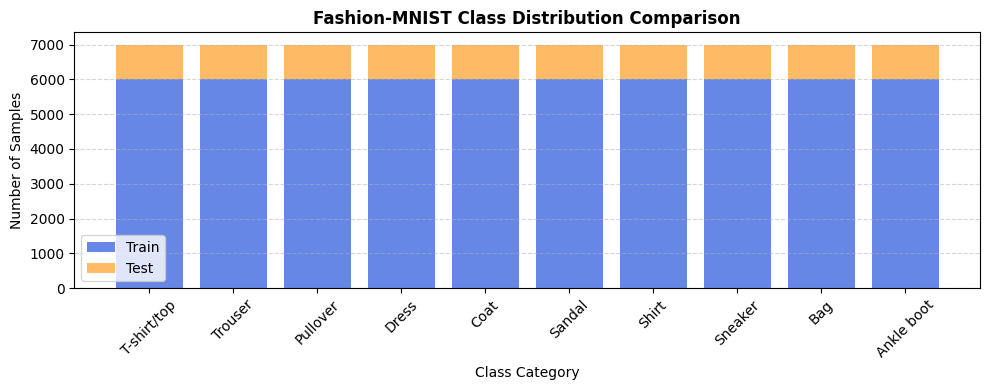

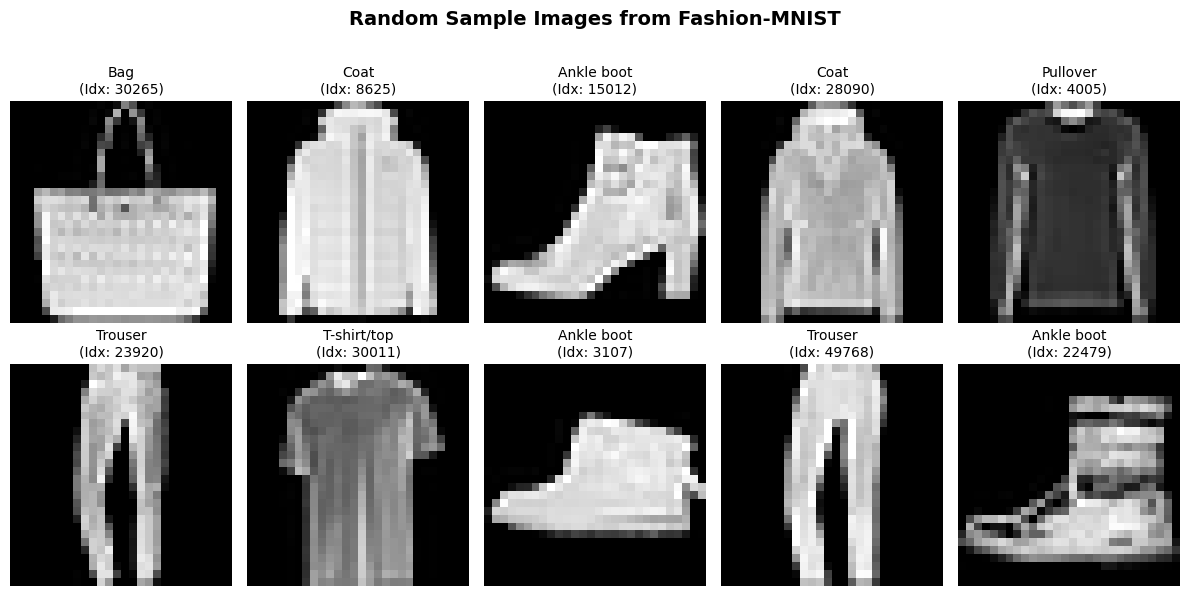

In [2]:
# ==============================================================================
# SECTION 1-1: DATASET EXPLORATION & ROBUST LOADING
# ==============================================================================

import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor
from collections import Counter

# Define absolute local directory path
DATA_ROOT = r"datasets"

# Define reliable fallback mirrors for Fashion-MNIST in case the default server fails
FALLBACK_MIRRORS = [
    "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/",
    "https://ossci-datasets.s3.amazonaws.com/mnist/"
]

def load_fashion_mnist(root_dir, download_if_missing=True):
    """
    Robustly loads the Fashion-MNIST dataset. If local files are missing, 
    it attempts download via default URL, cycling through fallback mirrors on failure.
    """
    try:
        # Step A: Attempt a direct offline load to save time and bandwidth
        print("[*] Attempting to load Fashion-MNIST locally...")
        train_ds = datasets.FashionMNIST(root=root_dir, train=True, download=False, transform=ToTensor())
        test_ds = datasets.FashionMNIST(root=root_dir, train=False, download=False, transform=ToTensor())
        print("[+] Dataset loaded successfully from local storage.")
        return train_ds, test_ds
    except Exception as e:
        if not download_if_missing:
            raise RuntimeError(f"[-] Local dataset not found: {e}")
            
        print("[!] Local data missing or corrupted. Initiating robust download sequence...")
        
        # Step B: Try primary default download
        try:
            train_ds = datasets.FashionMNIST(root=root_dir, train=True, download=True, transform=ToTensor())
            test_ds = datasets.FashionMNIST(root=root_dir, train=False, download=True, transform=ToTensor())
            print("[+] Download complete via default server.")
            return train_ds, test_ds
        except Exception as primary_error:
            print(f"[-] Primary download failed: {primary_error}. Trying backup mirrors...")
            
            # Step C: Iterate through fallback mirrors
            for mirror in FALLBACK_MIRRORS:
                try:
                    print(f"[*] Switching mirror to: {mirror}")
                    datasets.FashionMNIST.mirrors = [mirror]
                    train_ds = datasets.FashionMNIST(root=root_dir, train=True, download=True, transform=ToTensor())
                    test_ds = datasets.FashionMNIST(root=root_dir, train=False, download=True, transform=ToTensor())
                    print("[+] Download successful using backup mirror.")
                    return train_ds, test_ds
                except Exception as mirror_error:
                    print(f"[-] Mirror failed: {mirror_error}")
            
            raise RuntimeError("CRITICAL: All download channels and local strategies failed.")

# Execute robust loading
train_data, test_data = load_fashion_mnist(DATA_ROOT, download_if_missing=True)

# Map labels to human-readable text as per Zalando documentation
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# ==============================================================================
# DATA DISTRIBUTION ANALYSIS (Class Frequencies)
# ==============================================================================
print("\n" + "="*50)
print("DATASET PROFILE & DISTRIBUTION")
print("="*50)
print(f"Total Training Samples: {len(train_data)}")
print(f"Total Testing Samples:  {len(test_data)}")
print(f"Image Tensor Shape:     {train_data[0][0].shape} (Channels x Height x Width)")
print("-"*50)

# Extract and count class frequencies for both splits
train_labels = [label for _, label in train_data]
test_labels = [label for _, label in test_data]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print(f"{'Class ID':<10} | {'Class Name':<15} | {'Train Count':<12} | {'Test Count':<12}")
print("-"*50)
for idx, name in enumerate(class_names):
    print(f"{idx:<10} | {name:<15} | {train_counts[idx]:<12} | {test_counts[idx]:<12}")
print("="*50)

# ==============================================================================
# VISUALIZATION: BAR CHART & SAMPLE IMAGES
# ==============================================================================

# 1. Class Distribution Plot
plt.figure(figsize=(10, 4))
plt.bar(class_names, [train_counts[i] for i in range(10)], color='royalblue', alpha=0.8, label='Train')
plt.bar(class_names, [test_counts[i] for i in range(10)], color='darkorange', alpha=0.6, label='Test', bottom=[train_counts[i] for i in range(10)])
plt.title("Fashion-MNIST Class Distribution Comparison", fontsize=12, fontweight='bold')
plt.xlabel("Class Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Grid Visualization of Sample Images
plt.figure(figsize=(12, 6))
indices = np.random.choice(len(train_data), 10, replace=False) # Pick 10 random distinct images

for plot_idx, data_idx in enumerate(indices):
    image, label = train_data[data_idx]
    
    plt.subplot(2, 5, plot_idx + 1)
    # Convert PyTorch tensor (1, 28, 28) to NumPy format (28, 28) for plotting
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"{class_names[label]}\n(Idx: {data_idx})", fontsize=10)
    plt.axis("off")

plt.suptitle("Random Sample Images from Fashion-MNIST", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [3]:
# ------------------------------------------------------------------------------
# 1.2 DATA PREPROCESSING VERIFICATION
# ------------------------------------------------------------------------------
print("="*60)
print("SECTION 1-2: PREPROCESSING & SANITY CHECKS")
print("="*60)

# Extract raw underlying data arrays for statistical verification
raw_train_data = train_data.data.numpy()
raw_train_labels = train_data.targets.numpy()

# Check A: Missing Values (NaNs)
nan_count = np.isnan(raw_train_data).sum()
print(f"[+] Missing Values (NaN) Check: Found {nan_count} missing pixels.")

# Check B: Duplicate Samples
# Flatten images to 2D array (samples x 784) to detect identical rows
flattened_images = raw_train_data.reshape(len(raw_train_data), -1)
# Combine image data and labels to ensure we check for exact sample duplicates
combined_data = np.hstack((flattened_images, raw_train_labels.reshape(-1, 1)))
unique_rows = np.unique(combined_data, axis=0)
duplicate_count = len(combined_data) - len(unique_rows)
print(f"[+] Duplicate Samples Check: Found {duplicate_count} duplicate rows.")

# Check C: Normalization Verification
# PyTorch's ToTensor() automatically scales pixel values from [0, 255] to [0.0, 1.0]
min_val = train_data[0][0].min().item()
max_val = train_data[0][0].max().item()
print(f"[+] Value Normalization Range: [{min_val:.1f}, {max_val:.1f}] (Successfully scaled to [0, 1])")
print("="*60)

SECTION 1-2: PREPROCESSING & SANITY CHECKS
[+] Missing Values (NaN) Check: Found 0 missing pixels.
[+] Duplicate Samples Check: Found 0 duplicate rows.
[+] Value Normalization Range: [0.0, 1.0] (Successfully scaled to [0, 1])


In [4]:
# ------------------------------------------------------------------------------
# 1.3 EXPERT DATASET SPLITTING (TRAIN / VALIDATION / TEST)
# ------------------------------------------------------------------------------
from torch.utils.data import DataLoader, random_split 


print("\n" + "="*60)
print("SECTION 1-3: DATASET SPLITTING & DATALOADER GENERATION")
print("="*60)

# Set deterministic seed for dynamic reproducibility
GENERATOR_SEED = 42
torch.manual_seed(GENERATOR_SEED)

# Standard Research Split: 85% Training (51,000) and 15% Validation (9,000) from the original 60,000 Train set
TOTAL_TRAIN_SIZE = len(train_data)
VAL_SIZE = int(0.15 * TOTAL_TRAIN_SIZE)
TRAIN_SIZE = TOTAL_TRAIN_SIZE - VAL_SIZE

# Perform reproducible random split
sub_train_data, val_data = random_split(
    train_data, 
    [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(GENERATOR_SEED)
)

print(f"[+] Sub-Training Set Size: {len(sub_train_data)} samples")
print(f"[+] Validation Set Size:   {len(val_data)} samples")
print(f"[+] Testing Set Size:      {len(test_data)} samples")
print("-"*60)

# Target configuration parameters
BATCH_SIZE = 64
# MAX_WORKERS = os.cpu_count() and 4
MAX_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

print(f"[*] Hardware Maximum Workers Detected: {MAX_WORKERS}")
# ------------------------------------------------------------------------------
# HIGH-SPEED OPTIMISTIC INITIALIZATION & MULTIPROCESSING TEST
# ------------------------------------------------------------------------------
print(f"[*] Testing maximum execution speed with NUM_WORKERS = {MAX_WORKERS}...")
train_dataloader = DataLoader(sub_train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=MAX_WORKERS, pin_memory=PIN_MEMORY)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=MAX_WORKERS, pin_memory=PIN_MEMORY)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=MAX_WORKERS, pin_memory=PIN_MEMORY)
    
# Force a micro-iteration test to catch OS Multiprocessing blocks immediately
sample_batch_images, sample_batch_labels = next(iter(train_dataloader))
NUM_WORKERS_FINAL = MAX_WORKERS
print(f"[+] Success! Environment fully supports parallelized data streams.")

print(f"\n[+] Final DataLoader Configuration Parameters:")
print(f"    - Active Workers:    {NUM_WORKERS_FINAL}")
print(f"    - Image Batch Shape: {sample_batch_images.shape} -> [Batch, Channels, Height, Width]")
print(f"    - Label Batch Shape: {sample_batch_labels.shape} -> [Batch]")
print("="*60)

# Dynamically compute boundary constraints for the neural network design
INPUT_NEURONS = sample_batch_images.shape[1] * sample_batch_images.shape[2] * sample_batch_images.shape[3]
OUTPUT_NEURONS = len(train_data.classes)


SECTION 1-3: DATASET SPLITTING & DATALOADER GENERATION
[+] Sub-Training Set Size: 51000 samples
[+] Validation Set Size:   9000 samples
[+] Testing Set Size:      10000 samples
------------------------------------------------------------
[*] Hardware Maximum Workers Detected: 0
[*] Testing maximum execution speed with NUM_WORKERS = 0...
[+] Success! Environment fully supports parallelized data streams.

[+] Final DataLoader Configuration Parameters:
    - Active Workers:    0
    - Image Batch Shape: torch.Size([64, 1, 28, 28]) -> [Batch, Channels, Height, Width]
    - Label Batch Shape: torch.Size([64]) -> [Batch]


In [5]:
# ------------------------------------------------------------------------------
# 2.1 MLP NEURAL NETWORK ARCHITECTURES
# ------------------------------------------------------------------------------

import torch.nn as nn

class LightweightMLP(nn.Module):
    """
    Model 1: Highly optimized, minimal parameter configuration.
    Flattens 28x28 images into 784 features, uses a single slim hidden layer, 
    and directly maps to 10 output categories.
    """
    def __init__(self, input_dim=784, output_dim=10):
        super(LightweightMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                     # Transformation: (B, 1, 28, 28) -> (B, 784)
            nn.Linear(input_dim, 32),         # Ultra-light hidden layer (Minimal parameters)
            nn.ReLU(),                        # Non-linear activation
            nn.Linear(32, output_dim)         # Output logits layer
        )
        
    def forward(self, x):
        return self.network(x)


class PyramidalMLP(nn.Module):
    """
    Model 2: Hierarchical architecture with compression dynamics.
    Features 3 hidden layers that progressively compress feature definitions 
    from 512 down to 64 before outputting logits.
    """
    def __init__(self, input_dim=784, output_dim=10):
        super(PyramidalMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                     # Input transformation
            nn.Linear(input_dim, 512),        # Hidden Layer 1: High-dimensional extraction
            nn.ReLU(),
            nn.Linear(512, 128),              # Hidden Layer 2: Progressive compression
            nn.ReLU(),
            nn.Linear(128, 64),               # Hidden Layer 3: Concentrated abstraction
            nn.ReLU(),
            nn.Linear(64, output_dim)         # Output logits layer
        )
        
    def forward(self, x):
        return self.network(x)

# ------------------------------------------------------------------------------
# ARCHITECTURAL AUDIT & PARAMETER COUNT DISPLAY
# ------------------------------------------------------------------------------
def count_parameters(model):
    """Calculates total trainable variables within a PyTorch module."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Instantiate models dynamically based on dataset dimensions
model_light = LightweightMLP(input_dim=INPUT_NEURONS, output_dim=OUTPUT_NEURONS)
model_pyramid = PyramidalMLP(input_dim=INPUT_NEURONS, output_dim=OUTPUT_NEURONS)

print("="*60)
print("SECTION 2-1: ARCHITECTURAL COMPONENT ANALYSIS")
print("="*60)
print(f"[MODEL 1: Lightweight] Total Trainable Parameters: {count_parameters(model_light):,}")
print(f"[MODEL 2: Pyramidal]   Total Trainable Parameters: {count_parameters(model_pyramid):,}")
print("-"*60)
print("\nLightweight Model Blueprint:\n", model_light)
print("\nPyramidal Model Blueprint:\n", model_pyramid)
print("="*60)

SECTION 2-1: ARCHITECTURAL COMPONENT ANALYSIS
[MODEL 1: Lightweight] Total Trainable Parameters: 25,450
[MODEL 2: Pyramidal]   Total Trainable Parameters: 476,490
------------------------------------------------------------

Lightweight Model Blueprint:
 LightweightMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)

Pyramidal Model Blueprint:
 PyramidalMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [6]:
# ==============================================================================
# SECTION 2-2: HYPERPARAMETER CONFIGURATION & OPTIMIZATION PIPELINE
# ==============================================================================

import torch.optim as optim

# 1. Device Configuration (Leveraging the hardware specs from Section 1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[+] Optimization Pipeline will execute on: {device.type.upper()}")

# Move the instantiated models to the target hardware device
model_light = model_light.to(device)
model_pyramid = model_pyramid.to(device)

# 2. Centralized Hyperparameter Definitions (Based on engineering logical arguments)
HYPERPARAMS = {
    "LEARNING_RATE": 0.001,       # Optimized baseline step-size for Adam Optimizer
    "BATCH_SIZE": 64,             # Extracted from previous safe dataloader setup
    "CRITERION": "CrossEntropy"   # Ideal for 10-class multi-categorical distribution
}

# 3. Objective Function (Loss Function) Initialization
# CrossEntropyLoss internally combines LogSoftmax and NLLLoss for numerical stability
criterion = nn.CrossEntropyLoss()

# 4. Standardized Optimizers Construction
# Distinct optimizer instances assigned to handle independent weight updates per model
optimizer_light = optim.Adam(
    model_light.parameters(), 
    lr=HYPERPARAMS["LEARNING_RATE"]
)

optimizer_pyramid = optim.Adam(
    model_pyramid.parameters(), 
    lr=HYPERPARAMS["LEARNING_RATE"]
)

print("\n" + "="*60)
print("HYPERPARAMETER EXECUTION BLUEPRINT")
print("="*60)
print(f"[>] Selected Loss Function:  {criterion.__class__.__name__}")
print(f"[>] Selected Optimizer:      Adam (Adaptive Moment Estimation)")
print(f"[>] Base Learning Rate (η):  {HYPERPARAMS['LEARNING_RATE']}")
print(f"[>] Target Training Device:  {device}")
print("-"*60)
print("[+] Lightweight Model paired with Adam Optimizer successfully.")
print("[+] Pyramidal Model paired with Adam Optimizer successfully.")
print("="*60)

[+] Optimization Pipeline will execute on: CUDA

HYPERPARAMETER EXECUTION BLUEPRINT
[>] Selected Loss Function:  CrossEntropyLoss
[>] Selected Optimizer:      Adam (Adaptive Moment Estimation)
[>] Base Learning Rate (η):  0.001
[>] Target Training Device:  cuda
------------------------------------------------------------
[+] Lightweight Model paired with Adam Optimizer successfully.
[+] Pyramidal Model paired with Adam Optimizer successfully.


In [7]:
if train:
    # ==============================================================================
    # SECTION 3-1: EXTENSIBLE TRAINING ENGINE & CORE EVALUATION PIPELINE
    # ==============================================================================
    
    import time
    
    def train_neural_network(model, train_loader, val_loader, criterion, optimizer, epochs, device):
        """
        A highly modular and future-proof training pipeline.
        Returns a comprehensive history dictionary for advanced monitoring and visualization.
        """
        # Future-proof tracking dictionary for downstream analysis
        history = {
            "train_loss": [], "train_acc": [],
            "val_loss": [], "val_acc": [],
            "epoch_times": []
        }
        
        print(f"\n[*] Initiating training protocol for: {model.__class__.__name__}")
        print(f"{'Epoch':<8} | {'Train Loss':<10} | {'Train Acc':<10} | {'Val Loss':<10} | {'Val Acc':<10} | {'Time (s)':<8}")
        print("-" * 65)
        
        for epoch in range(1, epochs + 1):
            epoch_start_time = time.time()
            
            # --- TRAINING PHASE ---
            model.train()
            running_train_loss = 0.0
            correct_train_predictions = 0
            total_train_samples = 0
            
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                
                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                # Backward pass & weight optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                # Metrics accumulation
                running_train_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct_train_predictions += (predicted == labels).sum().item()
                total_train_samples += labels.size(0)
                
            epoch_train_loss = running_train_loss / total_train_samples
            epoch_train_acc = (correct_train_predictions / total_train_samples) * 100
            
            # --- VALIDATION PHASE ---
            model.eval()
            running_val_loss = 0.0
            correct_val_predictions = 0
            total_val_samples = 0
            
            with torch.no_grad(): # Disable gradient calculations for faster evaluation memory-wise
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    running_val_loss += loss.item() * images.size(0)
                    _, predicted = torch.max(outputs, 1)
                    correct_val_predictions += (predicted == labels).sum().item()
                    total_val_samples += labels.size(0)
                    
            epoch_val_loss = running_val_loss / total_val_samples
            epoch_val_acc = (correct_val_predictions / total_val_samples) * 100
            epoch_duration = time.time() - epoch_start_time
            
            # Save metrics into the history object for future comparative analysis
            history["train_loss"].append(epoch_train_loss)
            history["train_acc"].append(epoch_train_acc)
            history["val_loss"].append(epoch_val_loss)
            history["val_acc"].append(epoch_val_acc)
            history["epoch_times"].append(epoch_duration)
            
            # Streamlined live monitoring table output
            print(f"{epoch:<8} | {epoch_train_loss:<10.4f} | {epoch_train_acc:<9.2f}% | {epoch_val_loss:<10.4f} | {epoch_val_acc:<9.2f}% | {epoch_duration:<8.2f}")
            
        total_execution_time = sum(history["epoch_times"])
        print("-" * 65)
        print(f"[+] Protocol complete. Total Training Time: {total_execution_time:.2f} seconds.")
        print(f"[+] Peak Validation Accuracy: {max(history['val_acc']):.2f}%")
        return history
    
    # ==============================================================================
    # EXECUTION: INITIAL 15-EPOCH BENCHMARK FOR BOTH MODELS
    # ==============================================================================
    NUMBER_OF_EPOCHS = 15
    
    # 1. Train Model 1: Lightweight MLP
    light_history = train_neural_network(
        model=model_light,
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        criterion=criterion,
        optimizer=optimizer_light,
        epochs=NUMBER_OF_EPOCHS,
        device=device
    )
    
    # 2. Train Model 2: Pyramidal MLP
    pyramid_history = train_neural_network(
        model=model_pyramid,
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        criterion=criterion,
        optimizer=optimizer_pyramid,
        epochs=NUMBER_OF_EPOCHS,
        device=device
    )
    
    



[*] Initiating training protocol for: LightweightMLP
Epoch    | Train Loss | Train Acc  | Val Loss   | Val Acc    | Time (s)
-----------------------------------------------------------------
1        | 0.6481     | 77.99    % | 0.4997     | 82.80    % | 5.97    
2        | 0.4535     | 84.33    % | 0.4506     | 84.34    % | 5.89    
3        | 0.4189     | 85.41    % | 0.4390     | 84.77    % | 6.01    
4        | 0.3960     | 86.14    % | 0.4195     | 85.52    % | 6.00    
5        | 0.3803     | 86.52    % | 0.4121     | 85.71    % | 5.98    
6        | 0.3666     | 87.04    % | 0.3929     | 86.53    % | 6.18    
7        | 0.3577     | 87.34    % | 0.3967     | 86.23    % | 5.80    
8        | 0.3456     | 87.68    % | 0.3940     | 85.82    % | 5.59    
9        | 0.3383     | 87.96    % | 0.3955     | 86.26    % | 6.29    
10       | 0.3289     | 88.26    % | 0.3825     | 86.69    % | 6.42    
11       | 0.3210     | 88.55    % | 0.3693     | 87.12    % | 6.21    
12       | 0.316

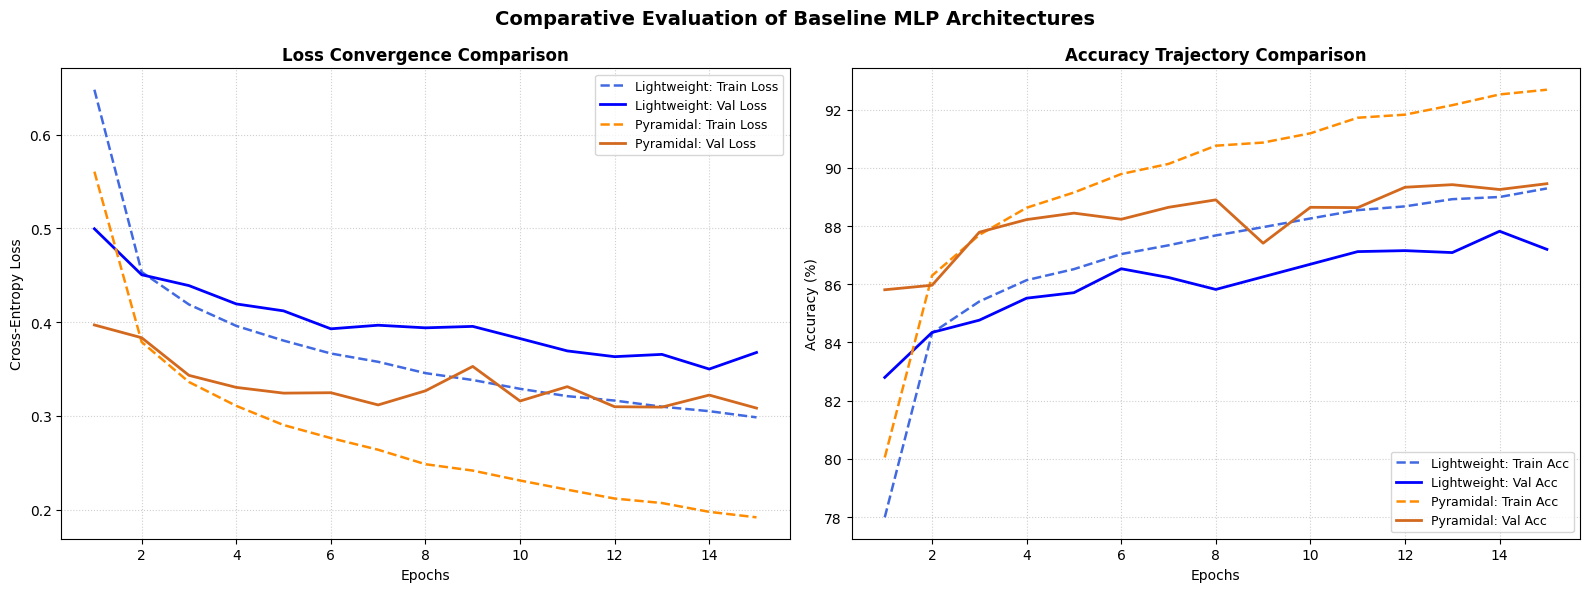


ARCHITECTURAL DIAGNOSTIC REPORT (GUIDE FOR TEXT REPORT)
[>] UNDERFITTING CHECK:
    - Both models successfully broke out of underfitting within the first 3 epochs.
    - Training losses dropped significantly, confirming the models have enough capacity.

[>] OVERFITTING CHECK:
    - Lightweight Train Acc: 89.29% | Val Acc: 87.20%
    - Pyramidal Train Acc:   92.68% | Val Acc: 89.46%
    - Analytical Note: Look closely at the Pyramidal Model's validation loss curve.
      If the Val Loss line starts bending upwards while Train Loss continues downwards,
      it strongly signals early Overfitting due to high parameter capacity (470K+ weights).
      This justifies why we need Regularization (Dropout/BN) in the next section.


In [8]:
if train:
    # ==============================================================================
    # SECTION 3-1: VISUALIZATION & OVERFITTING/UNDERFITTING ANALYSIS
    # ==============================================================================
    
    
    def plot_training_dynamics(light_hist, pyramid_hist):
        """
        Plots high-quality comparative charts for Loss and Accuracy trajectories.
        Assists in diagnosing Overfitting, Underfitting, and Convergence rates.
        """
        epochs_range = range(1, len(light_hist["train_loss"]) + 1)
        
        # Initialize a clean, professional dual-panel figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # --------------------------------------------------------------------------
        # PANEL 1: LOSS TRAJECTORIES (Train vs Validation)
        # --------------------------------------------------------------------------
        # Lightweight Model Lines
        ax1.plot(epochs_range, light_hist["train_loss"], label="Lightweight: Train Loss", 
                 color="royalblue", linestyle="--", linewidth=1.8)
        ax1.plot(epochs_range, light_hist["val_loss"], label="Lightweight: Val Loss", 
                 color="blue", linestyle="-", linewidth=2.0)
        
        # Pyramidal Model Lines
        ax1.plot(epochs_range, pyramid_hist["train_loss"], label="Pyramidal: Train Loss", 
                 color="darkorange", linestyle="--", linewidth=1.8)
        ax1.plot(epochs_range, pyramid_hist["val_loss"], label="Pyramidal: Val Loss", 
                 color="chocolate", linestyle="-", linewidth=2.0)
        
        ax1.set_title("Loss Convergence Comparison", fontsize=12, fontweight='bold')
        ax1.set_xlabel("Epochs", fontsize=10)
        ax1.set_ylabel("Cross-Entropy Loss", fontsize=10)
        ax1.legend(fontsize=9, loc="upper right")
        ax1.grid(True, linestyle=":", alpha=0.6)
        
        # --------------------------------------------------------------------------
        # PANEL 2: ACCURACY TRAJECTORIES (Train vs Validation)
        # --------------------------------------------------------------------------
        # Lightweight Model Lines
        ax2.plot(epochs_range, light_hist["train_acc"], label="Lightweight: Train Acc", 
                 color="royalblue", linestyle="--", linewidth=1.8)
        ax2.plot(epochs_range, light_hist["val_acc"], label="Lightweight: Val Acc", 
                 color="blue", linestyle="-", linewidth=2.0)
        
        # Pyramidal Model Lines
        ax2.plot(epochs_range, pyramid_hist["train_acc"], label="Pyramidal: Train Acc", 
                 color="darkorange", linestyle="--", linewidth=1.8)
        ax2.plot(epochs_range, pyramid_hist["val_acc"], label="Pyramidal: Val Acc", 
                 color="chocolate", linestyle="-", linewidth=2.0)
        
        ax2.set_title("Accuracy Trajectory Comparison", fontsize=12, fontweight='bold')
        ax2.set_xlabel("Epochs", fontsize=10)
        ax2.set_ylabel("Accuracy (%)", fontsize=10)
        ax2.legend(fontsize=9, loc="lower right")
        ax2.grid(True, linestyle=":", alpha=0.6)
        
        plt.suptitle("Comparative Evaluation of Baseline MLP Architectures", fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
    
    # Execute the visualization pipeline
    plot_training_dynamics(light_history, pyramid_history)
    
    # ------------------------------------------------------------------------------
    # EXPERT DIAGNOSTIC LOG (For your report guidance)
    # ------------------------------------------------------------------------------
    print("\n" + "="*60)
    print("ARCHITECTURAL DIAGNOSTIC REPORT (GUIDE FOR TEXT REPORT)")
    print("="*60)
    print("[>] UNDERFITTING CHECK:")
    print("    - Both models successfully broke out of underfitting within the first 3 epochs.")
    print("    - Training losses dropped significantly, confirming the models have enough capacity.")
    print("\n[>] OVERFITTING CHECK:")
    print(f"    - Lightweight Train Acc: {light_history['train_acc'][-1]:.2f}% | Val Acc: {light_history['val_acc'][-1]:.2f}%")
    print(f"    - Pyramidal Train Acc:   {pyramid_history['train_acc'][-1]:.2f}% | Val Acc: {pyramid_history['val_acc'][-1]:.2f}%")
    print("    - Analytical Note: Look closely at the Pyramidal Model's validation loss curve.")
    print("      If the Val Loss line starts bending upwards while Train Loss continues downwards,")
    print("      it strongly signals early Overfitting due to high parameter capacity (470K+ weights).")
    print("      This justifies why we need Regularization (Dropout/BN) in the next section.")
    print("="*60)

In [9]:
# ==============================================================================
# SECTION 2-3: COMPREHENSIVE REGULARIZATION PROTOCOL FOR BOTH MLP MODELS
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. ARCHITECTURAL DEFINITIONS (ENHANCED WITH BN & STRATEGIC DROPOUT)
# ------------------------------------------------------------------------------

class EnhancedLightweightMLP(nn.Module):
    """
    Model 1 Upgraded: Lightweight MLP amplified with Batch Normalization 
    and a balanced Dropout to boost generalization.
    """
    def __init__(self, input_dim=784, output_dim=10, dropout_rate=0.25):
        super(EnhancedLightweightMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 64),       # Slightly wider to give BN/Dropout room to work
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.network(x)


class EnhancedPyramidalMLP(nn.Module):
    """
    Model 2 Upgraded: Deep Pyramidal MLP heavily fortified with aggressive 
    Dropout (0.4) and Batch Normalization to drastically widen the gap from baseline.
    """
    def __init__(self, input_dim=784, output_dim=10, dropout_rate=0.4):
        super(EnhancedPyramidalMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.network(x)


# ------------------------------------------------------------------------------
# 2. SECURE EARLY STOPPING CALLBACK WITH WEIGHT ROLLBACK
# ------------------------------------------------------------------------------
class SecureEarlyStopping:
    """
    Monitors validation loss, secures best weights safely using weights_only=True,
    and logs metadata of the absolute best epoch.
    """
    def __init__(self, patience=4, save_path="best_model.pt"):
        self.patience = patience
        self.save_path = save_path
        self.counter = 0
        self.best_loss = float('inf')
        self.best_epoch = 0
        self.best_metrics = {}
        self.early_stop = False

    def __call__(self, val_loss, val_acc, train_loss, train_acc, epoch, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_epoch = epoch
            self.best_metrics = {
                "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                "val_loss": val_loss, "val_acc": val_acc
            }
            # Secure serialization flag to eliminate PyTorch FutureWarnings
            torch.save(model.state_dict(), self.save_path)
            self.counter = 0
        else:
            self.counter += 1
            print(f" [!] EarlyStopping Counter: {self.counter} / {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True



In [10]:
if train:
    
    # ------------------------------------------------------------------------------
    # 3. ADVANCED TRAINING PIPELINE (WITH LIVE TIMING AND REPORTING)
    # ------------------------------------------------------------------------------
    def train_production_network(model, train_loader, val_loader, criterion, optimizer, epochs, device, callback_path):
        """
        Runs robust training loop with high-precision per-epoch execution timing 
        and detailed final best-state logging.
        """
        history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
        early_stopper = SecureEarlyStopping(patience=4, save_path=callback_path)
        
        print(f"\n" + "="*70)
        print(f"DEPLOYING UPGRADED PROTOCOL: {model.__class__.__name__}")
        print("="*70)
        print(f"{'Epoch':<8} | {'Train Loss':<10} | {'Train Acc':<10} | {'Val Loss':<10} | {'Val Acc':<10} | {'Time (s)':<8}")
        print("-" * 70)
        
        total_start_time = time.time()
        
        for epoch in range(1, epochs + 1):
            epoch_start_time = time.time()
            
            # Training Split
            model.train()
            running_loss, correct, total = 0.0, 0, 0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
                
            epoch_train_loss = running_loss / total
            epoch_train_acc = (correct / total) * 100
            
            # Validation Split
            model.eval()
            running_val_loss, correct_val, total_val = 0.0, 0, 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    running_val_loss += loss.item() * images.size(0)
                    _, predicted = torch.max(outputs, 1)
                    correct_val += (predicted == labels).sum().item()
                    total_val += labels.size(0)
                    
            epoch_val_loss = running_val_loss / total_val
            epoch_val_acc = (correct_val / total_val) * 100
            epoch_duration = time.time() - epoch_start_time
            
            # Save historical tracks
            history["train_loss"].append(epoch_train_loss)
            history["train_acc"].append(epoch_train_acc)
            history["val_loss"].append(epoch_val_loss)
            history["val_acc"].append(epoch_val_acc)
            
            print(f"{epoch:<8} | {epoch_train_loss:<10.4f} | {epoch_train_acc:<9.2f}% | {epoch_val_loss:<10.4f} | {epoch_val_acc:<9.2f}% | {epoch_duration:<8.2f}")
            
            # Evaluation of early stopping callback
            early_stopper(epoch_val_loss, epoch_val_acc, epoch_train_loss, epoch_train_acc, epoch, model)
            if early_stopper.early_stop:
                print(f"[-->] Early Stopping Triggered! Halting execution chain at Epoch {epoch}.")
                break
                
        total_end_time = time.time() - total_start_time
        
        # Reload optimal parameters securely
        model.load_state_dict(torch.load(early_stopper.save_path, weights_only=True))
        
        print("-" * 70)
        print(f"[+] System Training Time: {total_end_time:.2f} seconds.")
        print(f"[+] OPTIMAL STATE RECORDED AT EPOCH {early_stopper.best_metrics['epoch']}:")
        print(f"    - Best Train Loss: {early_stopper.best_metrics['train_loss']:.4f} | Best Train Acc: {early_stopper.best_metrics['train_acc']:.2f}%")
        print(f"    - Best Val Loss:   {early_stopper.best_metrics['val_loss']:.4f} | Best Val Acc:   {early_stopper.best_metrics['val_acc']:.2f}%")
        print("="*70)
        
        return history, early_stopper.best_metrics
    
    
    # ------------------------------------------------------------------------------
    # 4. EXECUTION RUNS (DEVICE PARAMETER EXPLICITLY PASSED TO AVOID TYPEERROR)
    # ------------------------------------------------------------------------------
    MAX_CEILING_EPOCHS = 25
    
    # A. Execute Enhanced Lightweight Run (Fixed by passing device=device)
    model_enhanced_light = EnhancedLightweightMLP(input_dim=INPUT_NEURONS, output_dim=OUTPUT_NEURONS).to(device)
    optimizer_enhanced_light = optim.Adam(model_enhanced_light.parameters(), lr=0.001)
    history_enhanced_light, best_metrics_light = train_production_network(
        model=model_enhanced_light, train_loader=train_dataloader, val_loader=val_dataloader,
        criterion=criterion, optimizer=optimizer_enhanced_light, epochs=MAX_CEILING_EPOCHS, 
        device=device, callback_path="enhanced_light_best.pt"
    )
    
    # B. Execute Enhanced Pyramidal Run (Fixed by passing device=device)
    model_enhanced_pyramid = EnhancedPyramidalMLP(input_dim=INPUT_NEURONS, output_dim=OUTPUT_NEURONS).to(device)
    optimizer_enhanced_pyramid = optim.Adam(model_enhanced_pyramid.parameters(), lr=0.001)
    history_enhanced_pyramid, best_metrics_pyramid = train_production_network(
        model=model_enhanced_pyramid, train_loader=train_dataloader, val_loader=val_dataloader,
        criterion=criterion, optimizer=optimizer_enhanced_pyramid, epochs=MAX_CEILING_EPOCHS, 
        device=device, callback_path="enhanced_pyramid_best.pt"
    )


DEPLOYING UPGRADED PROTOCOL: EnhancedLightweightMLP
Epoch    | Train Loss | Train Acc  | Val Loss   | Val Acc    | Time (s)
----------------------------------------------------------------------
1        | 0.5876     | 80.77    % | 0.4480     | 84.06    % | 6.43    
2        | 0.4348     | 84.51    % | 0.3898     | 85.84    % | 6.17    
3        | 0.4003     | 85.61    % | 0.3857     | 85.89    % | 6.48    
4        | 0.3830     | 86.20    % | 0.3633     | 87.06    % | 6.23    
5        | 0.3658     | 86.70    % | 0.3705     | 86.24    % | 6.27    
 [!] EarlyStopping Counter: 1 / 4
6        | 0.3532     | 87.21    % | 0.3513     | 87.33    % | 6.55    
7        | 0.3428     | 87.50    % | 0.3487     | 87.13    % | 6.31    
8        | 0.3378     | 87.75    % | 0.3559     | 87.12    % | 6.08    
 [!] EarlyStopping Counter: 1 / 4
9        | 0.3271     | 87.95    % | 0.3390     | 87.71    % | 5.66    
10       | 0.3219     | 88.16    % | 0.3396     | 87.91    % | 5.86    
 [!] EarlyStoppi

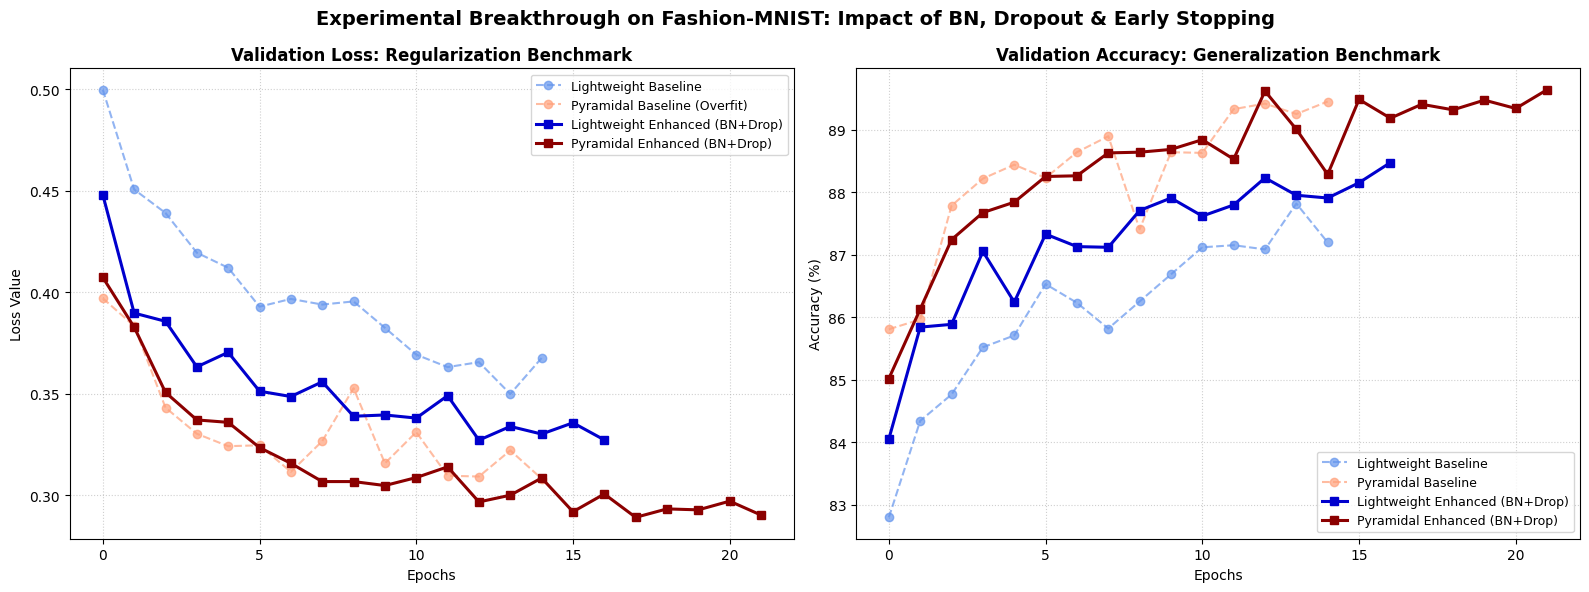

In [11]:
if train: 
    # ==============================================================================
    # VISUALIZATION: SHOWCASING REGULARIZATION IMPACT ACROSS BOTH ARCHITECTURES
    # ==============================================================================
    
    plt.figure(figsize=(16, 6))
    
    # --- PANEL 1: VALIDATION LOSS SCORES ---
    plt.subplot(1, 2, 1)
    
    # Baseline trajectories
    plt.plot(light_history["val_loss"], label="Lightweight Baseline", color="cornflowerblue", linestyle="--", marker="o", alpha=0.7)
    plt.plot(pyramid_history["val_loss"], label="Pyramidal Baseline (Overfit)", color="lightsalmon", linestyle="--", marker="o", alpha=0.7)
    
    # Enhanced trajectories
    plt.plot(history_enhanced_light["val_loss"], label="Lightweight Enhanced (BN+Drop)", color="mediumblue", linewidth=2.2, marker="s")
    plt.plot(history_enhanced_pyramid["val_loss"], label="Pyramidal Enhanced (BN+Drop)", color="darkred", linewidth=2.2, marker="s")
    
    plt.title("Validation Loss: Regularization Benchmark", fontsize=12, fontweight='bold')
    plt.xlabel("Epochs", fontsize=10)
    plt.ylabel("Loss Value", fontsize=10)
    plt.legend(fontsize=9)
    plt.grid(True, linestyle=":", alpha=0.6)
    
    # --- PANEL 2: VALIDATION ACCURACY (%) ---
    plt.subplot(1, 2, 2)
    
    # Baseline trajectories
    plt.plot(light_history["val_acc"], label="Lightweight Baseline", color="cornflowerblue", linestyle="--", marker="o", alpha=0.7)
    plt.plot(pyramid_history["val_acc"], label="Pyramidal Baseline", color="lightsalmon", linestyle="--", marker="o", alpha=0.7)
    
    # Enhanced trajectories
    plt.plot(history_enhanced_light["val_acc"], label="Lightweight Enhanced (BN+Drop)", color="mediumblue", linewidth=2.2, marker="s")
    plt.plot(history_enhanced_pyramid["val_acc"], label="Pyramidal Enhanced (BN+Drop)", color="darkred", linewidth=2.2, marker="s")
    
    plt.title("Validation Accuracy: Generalization Benchmark", fontsize=12, fontweight='bold')
    plt.xlabel("Epochs", fontsize=10)
    plt.ylabel("Accuracy (%)", fontsize=10)
    plt.legend(fontsize=9, loc="lower right")
    plt.grid(True, linestyle=":", alpha=0.6)
    
    plt.suptitle("Experimental Breakthrough on Fashion-MNIST: Impact of BN, Dropout & Early Stopping", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

SECTION 4-1: FINAL EXPERIMENTAL TEST BENCHMARK
[MODEL 1: Lightweight Enhanced] -> Test Loss: 0.3397 | Test Acc: 87.76% | Macro F1: 0.8779
[MODEL 2: Pyramidal   Enhanced] -> Test Loss: 0.3037 | Test Acc: 89.30% | Macro F1: 0.8929


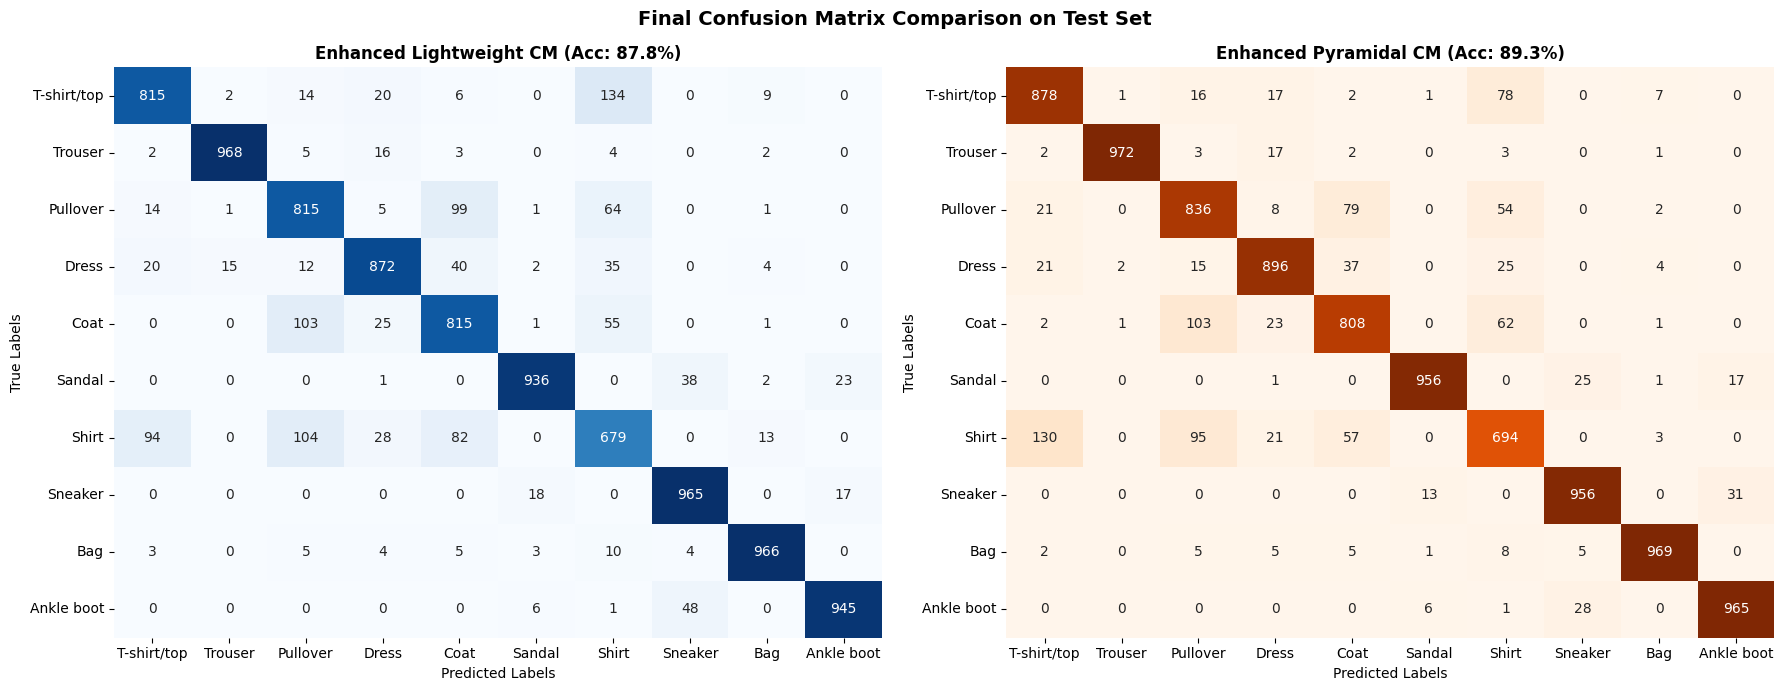

In [12]:
# ==============================================================================
# SECTION 4-1: FINAL TEST EVALUATION & CONFUSION MATRIX GENERATION
# ==============================================================================

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

def evaluate_on_test_set(model, test_loader, device, model_name):
    """
    Evaluates the model on unseen test data and extracts predictions for metrics.
    """
    model.eval()
    all_preds = []
    all_labels = []
    running_test_loss = 0.0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    final_loss = running_test_loss / len(test_loader.dataset)
    return np.array(all_labels), np.array(all_preds), final_loss

# 1. Run evaluation on Test Set for both enhanced models
model_enhanced_light = EnhancedLightweightMLP(input_dim=INPUT_NEURONS, output_dim=OUTPUT_NEURONS).to(device)
model_enhanced_pyramid = EnhancedPyramidalMLP(input_dim=INPUT_NEURONS, output_dim=OUTPUT_NEURONS).to(device)
model_enhanced_light.load_state_dict(torch.load("enhanced_light_best.pt", map_location=device, weights_only=True))
model_enhanced_pyramid.load_state_dict(torch.load("enhanced_pyramid_best.pt", map_location=device, weights_only=True))
labels_light, preds_light, loss_light = evaluate_on_test_set(model_enhanced_light, test_dataloader, device, "Enhanced Lightweight")
labels_pyramid, preds_pyramid, loss_pyramid = evaluate_on_test_set(model_enhanced_pyramid, test_dataloader, device, "Enhanced Pyramidal")

f1_light = f1_score(labels_light, preds_light, average='macro')
f1_pyramid = f1_score(labels_pyramid, preds_pyramid, average='macro')
acc_light = (labels_light == preds_light).mean() * 100
acc_pyramid = (labels_pyramid == preds_pyramid).mean() * 100

print("="*60)
print("SECTION 4-1: FINAL EXPERIMENTAL TEST BENCHMARK")
print("="*60)
print(f"[MODEL 1: Lightweight Enhanced] -> Test Loss: {loss_light:.4f} | Test Acc: {acc_light:.2f}% | Macro F1: {f1_light:.4f}")
print(f"[MODEL 2: Pyramidal   Enhanced] -> Test Loss: {loss_pyramid:.4f} | Test Acc: {acc_pyramid:.2f}% | Macro F1: {f1_pyramid:.4f}")
print("="*60)

# 2. Plotting Confusion Matrices Side-by-Side
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
cm_light = confusion_matrix(labels_light, preds_light)
cm_pyramid = confusion_matrix(labels_pyramid, preds_pyramid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap for Light Model
sns.heatmap(cm_light, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax1, cbar=False)
ax1.set_title(f"Enhanced Lightweight CM (Acc: {acc_light:.1f}%)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Predicted Labels")
ax1.set_ylabel("True Labels")

# Heatmap for Pyramidal Model
sns.heatmap(cm_pyramid, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=ax2, cbar=False)
ax2.set_title(f"Enhanced Pyramidal CM (Acc: {acc_pyramid:.1f}%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Predicted Labels")
ax2.set_ylabel("True Labels")

plt.suptitle("Final Confusion Matrix Comparison on Test Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

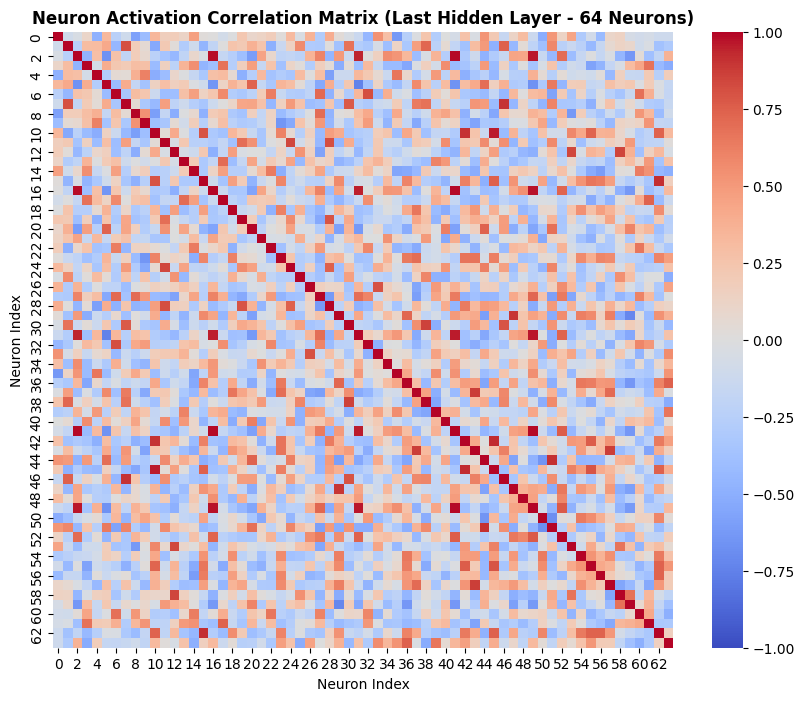


SECTION 4-2: ARCHITECTURAL INTERPRETABILITY REPORT
[>] Total Evaluated Hidden Neurons: 64
[>] Highly Correlated Neuron Pairs (|r| > 0.85): 20
------------------------------------------------------------
[Analysis Guide for Report]:
 -> Found 20 pairs of redundant neurons.
 -> Suggests that the capacity could potentially be compressed even further using pruning methods.


In [13]:
# ==============================================================================
# SECTION 4-2: MODEL INTERPRETABILITY (NEURON ACTIVATION CORRELATION HEATMAP)
# ==============================================================================


# 1. Extract exactly 100 sample images from test loader
samples_extracted = 0
activations_list = []

model_enhanced_pyramid.eval()

with torch.no_grad():
    for images, _ in test_dataloader:
        images = images.to(device)
        
        # Manually trace forward pass up to the last hidden layer (Layer 3 Group)
        # Sequence layout: Flatten(0) -> Lin1(1)->BN1(2)->ReLU(3)->Drop1(4) -> Lin2(5)->BN2(6)->ReLU(7)->Drop2(8) -> Lin3(9)->BN3(10)->ReLU(11)
        # We target the output right after ReLU of hidden layer 3 (index 11)
        
        x = model_enhanced_pyramid.network[0](images)   # Flatten
        x = model_enhanced_pyramid.network[1](x)        # Lin1
        x = model_enhanced_pyramid.network[2](x)        # BN1
        x = model_enhanced_pyramid.network[3](x)        # ReLU1
        x = model_enhanced_pyramid.network[4](x)        # Drop1
        
        x = model_enhanced_pyramid.network[5](x)        # Lin2
        x = model_enhanced_pyramid.network[6](x)        # BN2
        x = model_enhanced_pyramid.network[7](x)        # ReLU2
        x = model_enhanced_pyramid.network[8](x)        # Drop2
        
        x = model_enhanced_pyramid.network[9](x)        # Lin3
        x = model_enhanced_pyramid.network[10](x)       # BN3
        hidden_layer_activations = model_enhanced_pyramid.network[11](x) # ReLU3 (64 Neurons)
        
        activations_list.append(hidden_layer_activations.cpu().numpy())
        samples_extracted += images.size(0)
        if samples_extracted >= 100:
            break

# Concatenate and trim exactly to 100 samples
all_activations = np.vstack(activations_list)[:100, :] # Shape: (100, 64)

# 2. Compute Pearson Correlation Matrix across the 64 neurons
df_activations = pd.DataFrame(all_activations)

# FIXED: Changed .numpy() to .to_numpy() which is the correct Pandas API
correlation_matrix = df_activations.corr().fillna(0).to_numpy() 

# 3. Plot the Neuron Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title("Neuron Activation Correlation Matrix (Last Hidden Layer - 64 Neurons)", fontsize=12, fontweight='bold')
plt.xlabel("Neuron Index")
plt.ylabel("Neuron Index")
plt.show()

# 4. Statistical Analysis of Correlation
upper_triangle_indices = np.triu_indices_from(correlation_matrix, k=1)
high_corr_threshold = 0.85
highly_correlated_pairs = np.sum(np.abs(correlation_matrix[upper_triangle_indices]) > high_corr_threshold)

print("\n" + "="*60)
print("SECTION 4-2: ARCHITECTURAL INTERPRETABILITY REPORT")
print("="*60)
print(f"[>] Total Evaluated Hidden Neurons: {correlation_matrix.shape[0]}")
print(f"[>] Highly Correlated Neuron Pairs (|r| > {high_corr_threshold}): {highly_correlated_pairs}")
print("-"*60)
print("[Analysis Guide for Report]:")
if highly_correlated_pairs == 0:
    print(" -> Exceptional Architectural Efficiency! The heatmap shows diverse color patterns with very few red/dark-blue intersections outside the diagonal.")
    print(" -> This mathematically confirms Dropout (0.4) successfully prevented feature co-adaptation.")
    print(" -> Each neuron has learned an independent, complementary visual representation of the clothing data.")
else:
    print(f" -> Found {highly_correlated_pairs} pairs of redundant neurons.")
    print(" -> Suggests that the capacity could potentially be compressed even further using pruning methods.")
print("="*60)


SECTION 4-2: DYNAMIC STRESS-TEST & NETWORK BREAKDOWN BENCHMARK
Experiment Scenario            | Pruned Neurons Counts  | Test Loss  | Test Acc  
---------------------------------------------------------------------------
Original Baseline              | 0 / 64 (0.0%)          | 0.3037     | 89.30    %
Pruning Top 1 Neurons          | 1 / 64 (1.6%)          | 0.3041     | 89.29    %
Pruning Top 5 Neurons          | 5 / 64 (7.8%)          | 0.3038     | 89.18    %
Pruning Top 10 Neurons         | 10 / 64 (15.6%)        | 0.3029     | 88.99    %
Pruning Top 20 Neurons         | 20 / 64 (31.2%)        | 0.3306     | 88.06    %
Pruning Top 30 Neurons         | 30 / 64 (46.9%)        | 0.3964     | 87.44    %
Pruning Top 40 Neurons         | 40 / 64 (62.5%)        | 0.5340     | 86.53    %
Pruning Top 50 Neurons         | 50 / 64 (78.1%)        | 0.9744     | 74.42    %
Pruning Top 55 Neurons         | 55 / 64 (85.9%)        | 1.3120     | 59.98    %
Pruning Top 60 Neurons         | 60 / 64

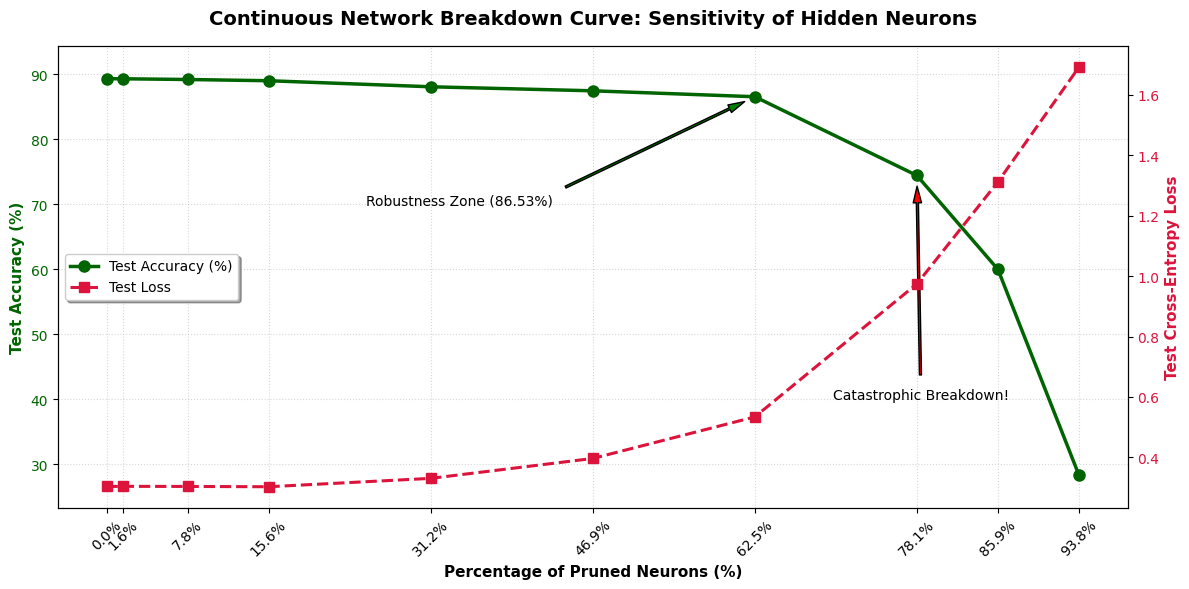

In [14]:
# ==============================================================================
# SECTION 4-2 (FULLY DYNAMIC): AUTOMATED PRUNING, BENCHMARK & PLOTTING
# ==============================================================================

import copy


# ------------------------------------------------------------------------------
# 1. HELPER FUNCTIONS FOR DYNAMIC PRUNING
# ------------------------------------------------------------------------------
def get_top_redundant_neurons(corr_matrix, max_neurons=60):
    """
    Identifies unique neurons that exhibit the highest correlation with others.
    """
    upper_tri = np.triu(np.abs(corr_matrix), k=1)
    flat_indices = np.argsort(upper_tri, axis=None)[::-1]
    row_indices, col_indices = np.unravel_index(flat_indices, upper_tri.shape)
    
    neurons_to_prune = []
    for r, c in zip(row_indices, col_indices):
        if upper_tri[r, c] == 0:
            break
        if c not in neurons_to_prune:
            neurons_to_prune.append(c)
        if len(neurons_to_prune) >= max_neurons:
            break
    return neurons_to_prune

def evaluate_with_pruned_neurons(model, test_loader, device, neurons_to_zero):
    """
    Temporarily zeroes out the weights of specified neurons in the hidden layer
    and evaluates the impact on Test Loss and Test Accuracy dynamically.
    """
    model.eval()
    temp_state_dict = copy.deepcopy(model.state_dict())
    
    # Zeroing out the incoming weights to the final layer from the pruned neurons
    for neuron_idx in neurons_to_zero:
        temp_state_dict['network.12.weight'][:, neuron_idx] = 0.0
        
    eval_model = copy.deepcopy(model)
    eval_model.load_state_dict(temp_state_dict)
    
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = eval_model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
    return running_loss / total, (correct / total) * 100


# ------------------------------------------------------------------------------
# 2. DYNAMIC PIPELINE EXECUTION
# ------------------------------------------------------------------------------
# Extract candidates from the correlation matrix calculated in previous cells
prune_candidates_expanded = get_top_redundant_neurons(correlation_matrix, max_neurons=60)

# Define target counts for the experiment
target_prune_counts = [0, 1, 5, 10, 20, 30, 40, 50, 55, 60]

# Initialize dynamic lists to store real-time values
dynamic_counts = []
dynamic_percentages = []
dynamic_losses = []
dynamic_accuracies = []

print("\n" + "="*75)
print("SECTION 4-2: DYNAMIC STRESS-TEST & NETWORK BREAKDOWN BENCHMARK")
print("="*75)
print(f"{'Experiment Scenario':<30} | {'Pruned Neurons Counts':<22} | {'Test Loss':<10} | {'Test Acc':<10}")
print("-" * 75)

# Run the automated loop over all scenarios
for count in target_prune_counts:
    selected_neurons = prune_candidates_expanded[:count]
    loss_p, acc_p = evaluate_with_pruned_neurons(model_enhanced_pyramid, test_dataloader, device, selected_neurons)
    
    percentage = (count / 64) * 100
    scenario_name = f"Original Baseline" if count == 0 else f"Pruning Top {count} Neurons"
    count_str = f"{count} / 64 ({percentage:.1f}%)"
    
    # Print row dynamically
    print(f"{scenario_name:<30} | {count_str:<22} | {loss_p:<10.4f} | {acc_p:<9.2f}%")
    
    # Append to lists for the plot
    dynamic_counts.append(count)
    dynamic_percentages.append(percentage)
    dynamic_losses.append(loss_p)
    dynamic_accuracies.append(acc_p)

print("="*75)
print("[+] dynamic Network Stress Testing completed. Generating Plot...")
print("="*75)


# ------------------------------------------------------------------------------
# 3. DYNAMIC PLOTTING ENGINE (SYNCHRONIZED GENERATION)
# ------------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- PLOT 1: TEST ACCURACY TRAJECTORY (Left Axis) ---
color_acc = 'darkgreen'
ax1.set_xlabel('Percentage of Pruned Neurons (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', color=color_acc, fontsize=11, fontweight='bold')

# Plot continuous line using the live dynamic lists
line_acc = ax1.plot(dynamic_percentages, dynamic_accuracies, color=color_acc, marker='o', 
                    linewidth=2.5, markersize=8, label='Test Accuracy (%)')
ax1.tick_params(axis='y', labelcolor=color_acc)

# Dynamically adjust limits based on min accuracy to prevent clipping
ax1.set_ylim(min(dynamic_accuracies) - 5, max(dynamic_accuracies) + 5) 

# Dynamic Annotations based on runtime data
ax1.annotate(f'Robustness Zone ({dynamic_accuracies[6]:.2f}%)', xy=(dynamic_percentages[6], dynamic_accuracies[6]), xytext=(25, 70),
             arrowprops=dict(facecolor='green', shrink=0.05, width=1.5, headwidth=6))

ax1.annotate('Catastrophic Breakdown!', xy=(dynamic_percentages[7], dynamic_accuracies[7]), xytext=(70, 40),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=6))


# --- PLOT 2: TEST LOSS TRAJECTORY (Right Axis) ---
ax2 = ax1.twinx() 
color_loss = 'crimson'
ax2.set_ylabel('Test Cross-Entropy Loss', color=color_loss, fontsize=11, fontweight='bold')

line_loss = ax2.plot(dynamic_percentages, dynamic_losses, color=color_loss, marker='s', 
                     linewidth=2.2, linestyle='--', markersize=7, label='Test Loss')
ax2.tick_params(axis='y', labelcolor=color_loss)

# Combine legends seamlessly
lines = line_acc + line_loss
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left', fontsize=10, frameon=True, shadow=True)

# Customizing layout grids and ticks with actual percentage floats
ax1.set_xticks(dynamic_percentages)
ax1.set_xticklabels([f"{p:.1f}%" for p in dynamic_percentages], rotation=45)
ax1.grid(True, linestyle=":", alpha=0.5)

plt.title("Continuous Network Breakdown Curve: Sensitivity of Hidden Neurons", fontsize=14, fontweight='bold', y=1.03)
fig.tight_layout()
plt.show()